<a href="https://colab.research.google.com/github/anisaratna/credit-risk-engine-ml/blob/main/Fintech_Loan_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LOAD DATA:


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import time
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, roc_curve , confusion_matrix, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from google.colab import drive
import sys

In [2]:
# 1. Definisi Path
folder_path = '/content/drive/My Drive/Project Portofolio/Project 2 Credit Risk Analysis/'
file_name = 'credit_risk_dataset.csv'

# 2. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 3. Tambahkan path ke sistem
sys.path.append(folder_path)

# 4. List Column Names
column_names = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_status",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

# 5. Load Data
df = pd.read_csv(f'{folder_path}{file_name}')

# 6. Backup Data Original
original_df = df.copy()

# 7. Tampilkan info dasar
print(f"Data Berhasil Dimuat!")
print(f"Jumlah Baris: {df.shape[0]} | Jumlah Kolom: {df.shape[1]}")
df.head()

Mounted at /content/drive
Data Berhasil Dimuat!
Jumlah Baris: 32581 | Jumlah Kolom: 12


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# EDA:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
# Cek Duplikat
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 165


In [5]:
# Cek Missing Values
print("\nKolom dengan data kosong:")
print(df.isnull().sum())


Kolom dengan data kosong:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [6]:
# Statistik deskriptif untuk variabel numerik

df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
# Statistik deskriptif untuk variabel kategorikal
df.describe(include=['object'])

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [8]:
# Outlier
df_numeric = df.select_dtypes(include=['number'])
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).sum()
outliers_sorted = outliers.sort_values(ascending=False)
print("\nJumlah Outlier Berdasarkan IQR:\n", outliers_sorted)


Jumlah Outlier Berdasarkan IQR:
 loan_status                   7108
loan_amnt                     1689
person_age                    1494
person_income                 1484
cb_person_cred_hist_length    1142
person_emp_length              853
loan_percent_income            651
loan_int_rate                    6
dtype: int64


/tmp/ipykernel_2297/3862333175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_status', data=df, palette='viridis')


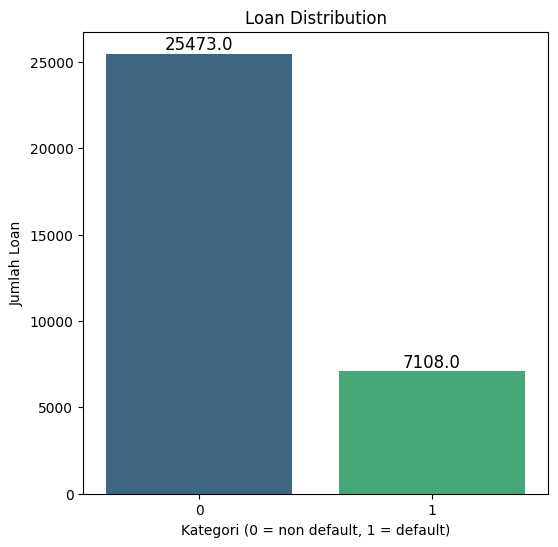

In [9]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(x='loan_status', data=df, palette='viridis')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12, color='black')

plt.xlabel("Kategori (0 = non default, 1 = default)")
plt.ylabel("Jumlah Loan")
plt.title("Loan Distribution")
plt.show()

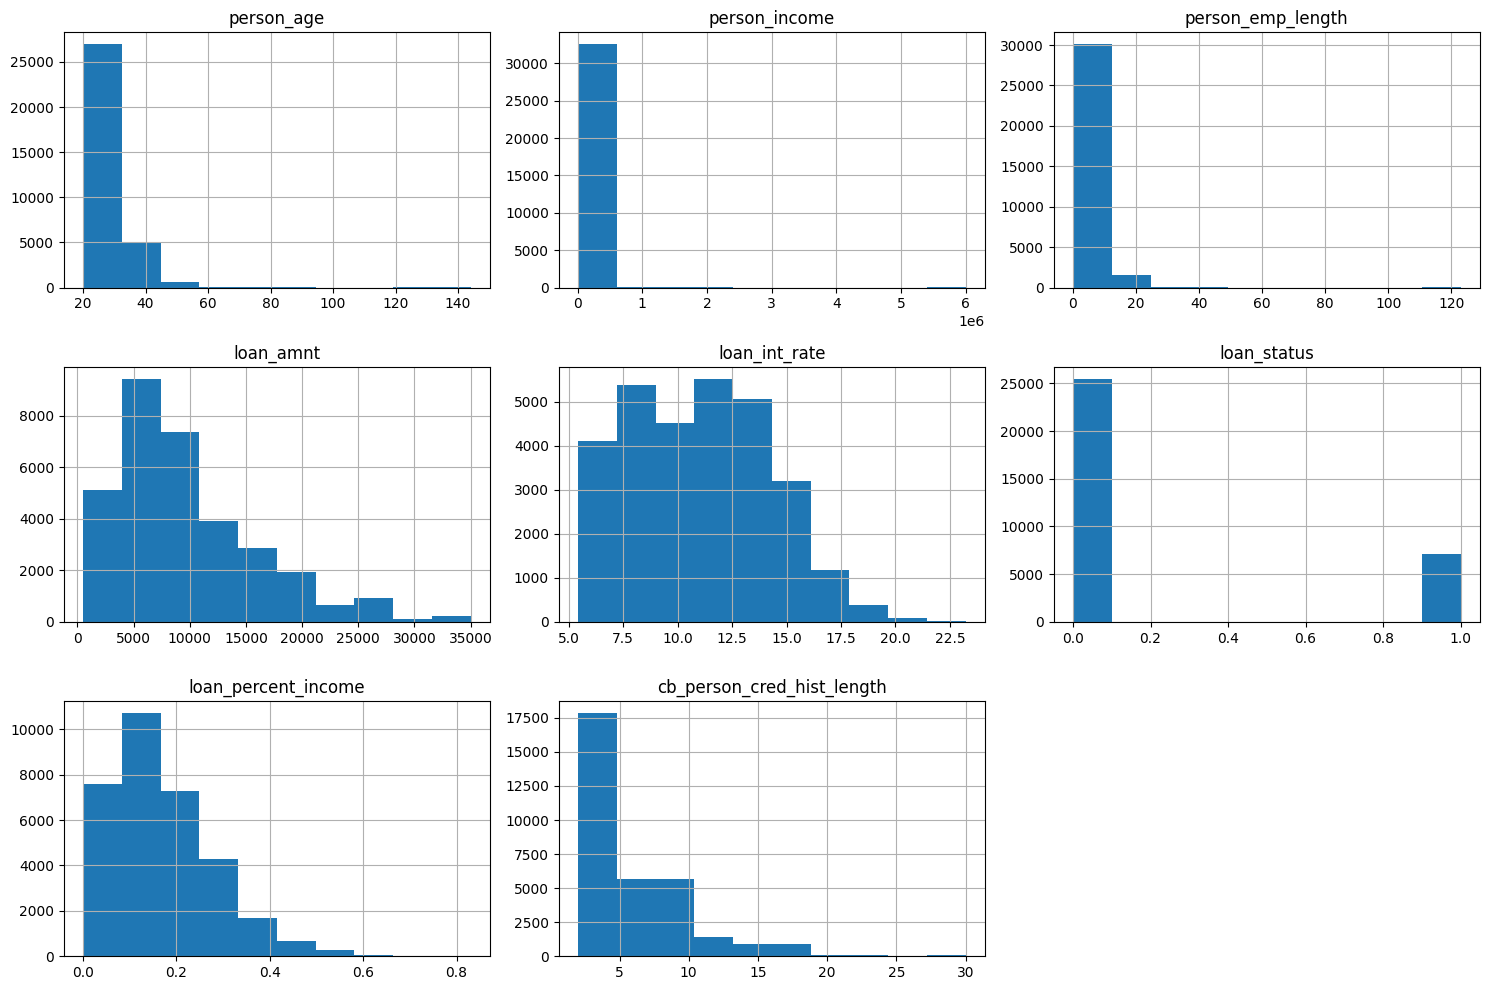

In [10]:
# Histogram untuk variabel numerik
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

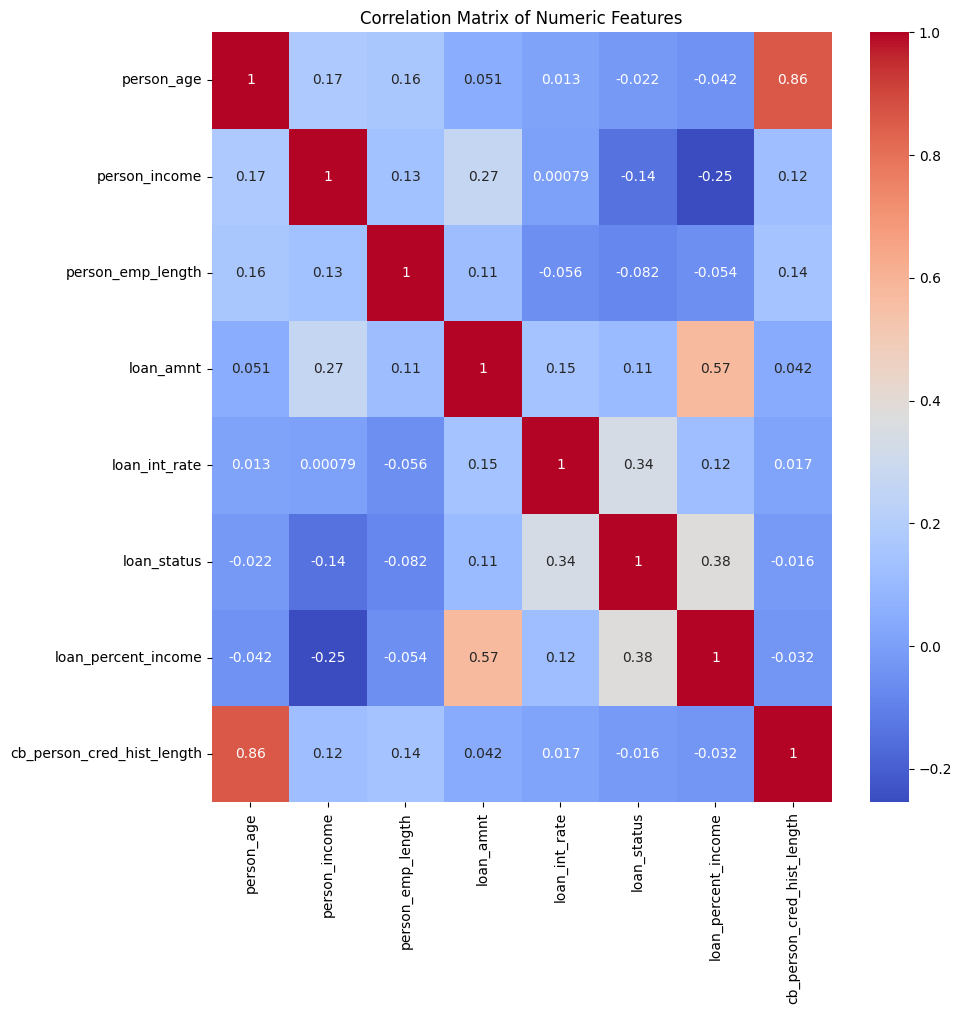

In [11]:
# Korelasi antara variabel numerik
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# Data Cleaning:

In [12]:
# Delate Outlier Age and Emp Length
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

In [13]:
# Capping Outlier person_income (Persentil 99)
upper_limit = df['person_income'].quantile(0.99)
df['person_income'] = df['person_income'].clip(upper=upper_limit)

/tmp/ipykernel_2297/30341500.py:3: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['person_income'] = df['person_income'].clip(upper=upper_limit)


In [14]:
# Menghapus Duplikat
df = df.drop_duplicates()

In [15]:
# Drop fitur (Multicollinearity)
df = df.drop(columns=['cb_person_cred_hist_length'])

In [16]:
# Menangani Missing Value person emp length
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [17]:
print("Cleaning Selesai!")
print(f"Ukuran data final: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")
print(f"Max Age: {df['person_age'].max()}")
print(f"Max Emp Length: {df['person_emp_length'].max()}")
print(f"Jumlah Missing Value:\n{df.isnull().sum()}")

Cleaning Selesai!
Ukuran data final: (31522, 11)
Kolom tersedia: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file']
Max Age: 94
Max Emp Length: 41.0
Jumlah Missing Value:
person_age                   0
person_income                0
person_home_ownership        0
person_emp_length            0
loan_intent                  0
loan_grade                   0
loan_amnt                    0
loan_int_rate                0
loan_status                  0
loan_percent_income          0
cb_person_default_on_file    0
dtype: int64


# Preprocessing:


In [18]:
# ONE-HOT ENCODING
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [19]:
# MEMISAHKAN FITUR DAN TARGET
X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']

In [20]:
# TRAIN-TEST SPLIT (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data sebelum SMOTE (Training Set):")
print(y_train.value_counts())


Jumlah data sebelum SMOTE (Training Set):
loan_status
0    19772
1     5445
Name: count, dtype: int64


In [21]:
# PENERAPAN SMOTE (Hanya pada Training Set)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"\nJumlah data setelah SMOTE (Training Set):")
print(y_train_res.value_counts())


Jumlah data setelah SMOTE (Training Set):
loan_status
0    19772
1    19772
Name: count, dtype: int64


# Modelling:

In [22]:
# Inisialisasi Model XGBoost
model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Melatih model menggunakan data hasil SMOTE (X_train_res)
model_xgb.fit(X_train_res, y_train_res)

# Melakukan Prediksi pada Data Uji (X_test)
y_pred = model_xgb.predict(X_test)

# Evaluasi Awal
print("--- Baseline XGBoost Performance ---")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:49:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Baseline XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      4943
           1       0.90      0.72      0.80      1362

    accuracy                           0.92      6305
   macro avg       0.91      0.85      0.88      6305
weighted avg       0.92      0.92      0.92      6305



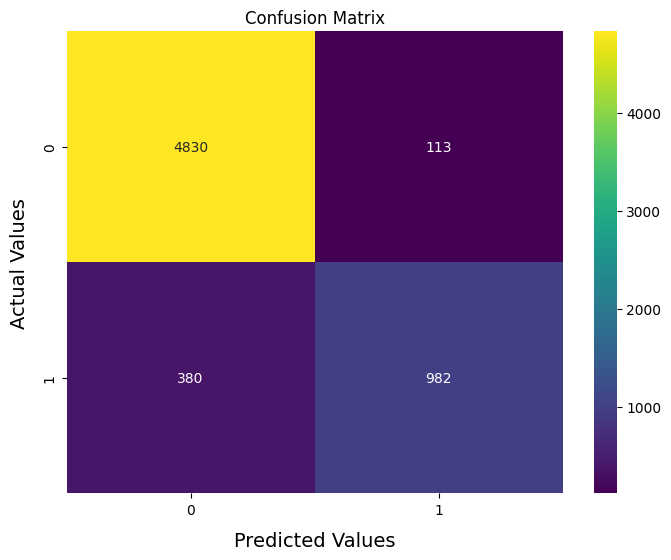

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, cmap='viridis', fmt='.0f')
plt.xlabel('Predicted Values', fontdict={'size':14}, labelpad=10)
plt.ylabel('Actual Values', fontdict={'size':14}, labelpad=10)
plt.title('Confusion Matrix')
plt.show()

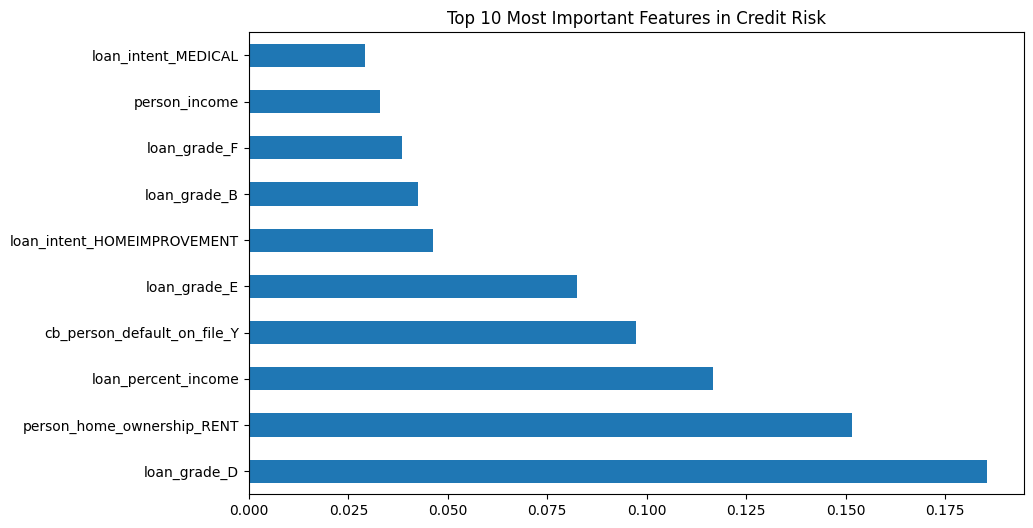

In [24]:
# Feature Importance Visualization
feat_importances = pd.Series(model_xgb.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Most Important Features in Credit Risk')
plt.show()

In [25]:
from sklearn.model_selection import RandomizedSearchCV

# Menentukan parameter uji
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Inisialisasi Randomized Search
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Menjalankan pencarian
print("Sedang mencari parameter terbaik...")
random_search.fit(X_train_res, y_train_res)

# Mengambil model terbaik
best_model = random_search.best_estimator_

# Evaluasi Akhir
y_pred_tuned = best_model.predict(X_test)
print("\n--- Tuned XGBoost Performance ---")
print(classification_report(y_test, y_pred_tuned))
print(f"Best Parameters: {random_search.best_params_}")

Sedang mencari parameter terbaik...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:50:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Tuned XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      4943
           1       0.94      0.76      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.94      0.87      0.90      6305
weighted avg       0.94      0.94      0.94      6305

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [28]:
import joblib
from google.colab import files

joblib.dump(best_model, 'credit_risk_model.pkl')

joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("File berhasil dibuat! Sedang mendownload...")

files.download('credit_risk_model.pkl')
files.download('model_columns.pkl')

File berhasil dibuat! Sedang mendownload...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>